In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [23]:
!pip install dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# **Mlflow and dagshub initialisation**

In [24]:
import dagshub
dagshub.init(repo_owner='luchit22', repo_name='ML-house-prices-prediction', mlflow=True)



❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9964b15e-776b-4e70-b44e-6ab419c3c496&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e47f60825626ccf2a653775a839a328db5a7ed5a5afd0a0ee6c03c7508783c32




Output()

Accessing as luchit22

Initialized MLflow to track repo "luchit22/ML-house-prices-prediction"

Repository luchit22/ML-house-prices-prediction initialized!

In [25]:
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
test_ids = test['Id']

# **data cleaning**

In [28]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [62]:
train.shape

(1460, 81)

In [63]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**საჭიროა რომ გვესმოდეს რა ინფორმაციის მატარებელია თითოეული სვეტის შიგთავსი რომ მივხვდეთ მათ მნიშვნელობებს**

In [38]:
with open('/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt', 'r') as f:
    description = f.read()
print(description)

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [119]:
missing_data = train.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print("missing values number\n", missing_data)
missing_data = test.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print("missing values number\n", missing_data)


def clean_data_option1(df):
    df_clean = df.copy()
    
    threshold = len(df_clean) * 0.6
    df_clean = df_clean.dropna(thresh=threshold, axis=1)
    
    for col in df_clean.columns:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            
    return df_clean


def clean_data_option2(df):
    df_clean = df.copy()
    
    none_features = [
        'Alley', 'PoolQC', 'MiscFeature', 'Fence', 'FireplaceQu',
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'MasVnrType'
    ]
    for col in none_features:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna('None')
            
    zero_features = [
        'GarageYrBlt', 'GarageArea', 'GarageCars',
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 
        'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
    ]
    for col in zero_features:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(0)
            
    mode_features = [
        'MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 
        'Exterior2nd', 'SaleType', 'Utilities', 'Functional'
    ]
    for col in mode_features:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            
    if 'LotFrontage' in df_clean.columns:
        df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
            lambda x: x.fillna(x.median())
        )
        df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())
        
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if df_clean[col].dtype == 'object':
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
                
    return df_clean
train_c1 = clean_data_option1(train)
test_c1 = clean_data_option1(test)
train_c2 = clean_data_option2(train)
test_c2 = clean_data_option2(test)

print(f"NA in Train: {train_c1.isnull().sum().max()}")
print(f"NA in Test: {test_c1.isnull().sum().max()}")
print(f"NA in Train: {train_c2.isnull().sum().max()}")
print(f"NA in Test: {test_c2.isnull().sum().max()}")

missing values number
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64
missing values number
 PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageQual        78
GarageCond        78
GarageYrBlt       78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
Exterior1st        1
Exterior2nd        1
TotalBsmtSF      

/tmp/ipykernel_55/4206898251.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipykernel_55/4206898251.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

# **feature engineering**

**ზოგი ფიჩერი მიუთითებს ხარისხს და ჩავანაცვლოთ მაგ სტრატეგიით**

In [121]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_columns = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

def encode_ordinal(df):
    df_encoded = df.copy()
    for col in qual_columns:
        if col in df_encoded.columns:
            df_encoded[col] = df_encoded[col].map(quality_map)
    return df_encoded

train_c1 = encode_ordinal(train_c1)
test_c1 = encode_ordinal(test_c1)
train_c2 = encode_ordinal(train_c2)
test_c2 = encode_ordinal(test_c2)

**გავაერთიანოთ ფიჩერები შინაარსის მიხედვით**

In [122]:
def add_new_features(df, drop_old=True):
    df_new = df.copy()
    
    df_new['TotalSF'] = df_new['TotalBsmtSF'] + df_new['1stFlrSF'] + df_new['2ndFlrSF']
    
    df_new['TotalBath'] = df_new['FullBath'] + (0.5 * df_new['HalfBath']) + \
                          df_new['BsmtFullBath'] + (0.5 * df_new['BsmtHalfBath'])
    
    if drop_old:
        cols_to_drop = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 
                        'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
        cols_to_drop = [c for c in cols_to_drop if c in df_new.columns]        
        df_new = df_new.drop(columns=cols_to_drop) 
    return df_new

train_c1 = add_new_features(train_c1)
test_c1 = add_new_features(test_c1)
train_c2 = add_new_features(train_c2)
test_c2 = add_new_features(test_c2)

**გამოვიყენოთ ვან ჰოთ ენკოდინგი**

In [124]:
categorical_cols_c1 = train_c1.select_dtypes(include=['object']).columns
categorical_cols_c2 = train_c2.select_dtypes(include=['object']).columns


train_final_c1 = pd.get_dummies(train_c1, columns=categorical_cols_c1)
test_final_c1 = pd.get_dummies(test_c1, columns=categorical_cols_c1)
train_final_c2 = pd.get_dummies(train_c2, columns=categorical_cols_c2)
test_final_c2 = pd.get_dummies(test_c2, columns=categorical_cols_c2)

final_train_cols_c1 = train_final_c1.columns.intersection(test_final_c1.columns).tolist()
y_c1 = train_final_c1['SalePrice']
X_c1 = train_final_c1[final_train_cols_c1]
X_test_c1 = test_final_c1[final_train_cols_c1]

final_train_cols_c2 = train_final_c2.columns.intersection(test_final_c2.columns).tolist()
y_c2 = train_final_c2['SalePrice']
X_c2 = train_final_c2[final_train_cols_c2]
X_test_c2 = test_final_c2[final_train_cols_c2]

print(f"feature num: {X_c1.shape[1]}")
print(f"feature num: {X_c2.shape[1]}")

feature num: 219
feature num: 242


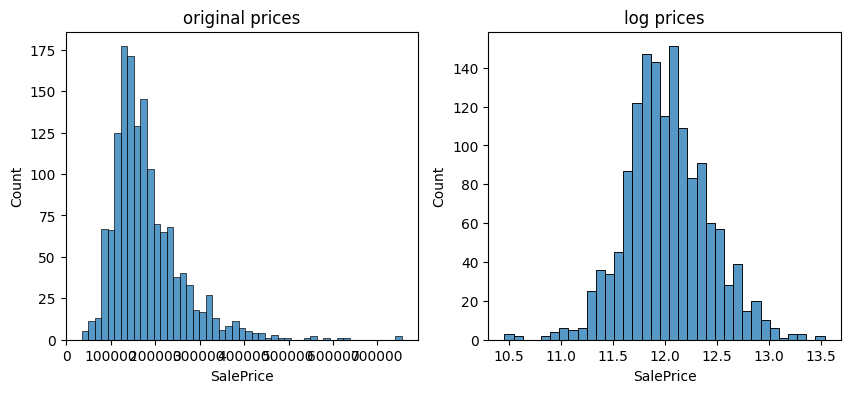

In [125]:
y_log = np.log1p(y)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); sns.histplot(y); plt.title("original prices")
plt.subplot(1,2,2); sns.histplot(y_log); plt.title("log prices")
plt.show()

# **feature selection**

In [129]:
def corr_to_y(df, df_test):
    temp_df = df.copy()
    temp_df['SalePrice_Log'] = y_log

    correlations = temp_df.corr()['SalePrice_Log'].abs()

    threshold = 0.15
    selected_cols_corr = correlations[correlations > threshold].index.tolist()
    selected_cols_corr.remove('SalePrice_Log')
    
    X_corr_selected = df[selected_cols_corr]
    X_test_corr_selected = df_test[selected_cols_corr]
    return X_corr_selected, X_test_corr_selected

X_c1_corr , X_test_c1_corr = corr_to_y(X_c1, X_test_c1)
X_c2_corr , X_test_c2_corr = corr_to_y(X_c2, X_test_c2)
print(f"before: {X_c1.shape[1]}")
print(f"after: {X_c1_corr.shape[1]}")
print(f"before: {X_c2.shape[1]}")
print(f"after: {X_c2_corr.shape[1]}")

before: 219
after: 68
before: 242
after: 78


In [130]:
def corr_to_each(df,df_test):
    corr_matrix = df.corr().abs()
    
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    high_corr_threshold = 0.85
    to_drop_multicollinear = [column for column in upper_triangle.columns if any(upper_triangle[column] > high_corr_threshold)]
    
    X_corr = df.drop(columns=to_drop_multicollinear)
    X_test_corr = df_test.drop(columns=to_drop_multicollinear)
    return X_corr, X_test_corr

X_c1_corr , X_test_c1_corr = corr_to_each(X_c1_corr, X_test_c1_corr)
X_c2_corr , X_test_c2_corr = corr_to_each(X_c2_corr, X_test_c2_corr)
print(f"num: {X_c1_corr.shape[1]}")
print(f"num: {X_c2_corr.shape[1]}")

num: 57
num: 63


In [133]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

def rand_forest_reg(df,df_test):
    rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_selector.fit(df, y_log)

    #60 ვწერ რადგან მაინტერესებს საშუალოდ რომელი მომცემს უკეთესს შედეგს ერთი და იმავე რაოდენობაზე
    selector = SelectFromModel(rf_selector,threshold=-np.inf, max_features=60, prefit=True)
    X_rf_selected_array = selector.transform(df)
    X_test_rf_selected_array = selector.transform(df_test)
    selected_features_mask = selector.get_support()
    selected_cols_rf = df.columns[selected_features_mask]

    X_rf_selected = pd.DataFrame(X_rf_selected_array, columns=selected_cols_rf)
    X_test_rf_selected = pd.DataFrame(X_test_rf_selected_array, columns=selected_cols_rf)
    return X_rf_selected, X_test_rf_selected

X_c1_rf , X_test_c1_rf = rand_forest_reg(X_c1,X_test_c1)
X_c2_rf , X_test_c2_rf = rand_forest_reg(X_c2,X_test_c2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


# **Training**

In [134]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

datasets = {
    "base_clean_with_corr": X_c1_corr,
    "base_clean_with_rf": X_c1_rf,
    "advanced_clean_with_corr": X_c2_corr,
    "advanced_clean_with_rf": X_c2_rf
}

for data_name, X_data in datasets.items():
    X_train, X_val, y_train, y_val = train_test_split(X_data, y_log, test_size=0.2, random_state=42)
    
    mlflow.set_experiment("linear_regression")
    
    run_name_lr = f"LR_{data_name}"
    with mlflow.start_run(run_name=run_name_lr):
        model_lr = LinearRegression()
        model_lr.fit(X_train, y_train)
        
        train_preds_lr = model_lr.predict(X_train)
        val_preds_lr = model_lr.predict(X_val)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, train_preds_lr))
        val_rmse = np.sqrt(mean_squared_error(y_val, val_preds_lr))
        train_r2 = r2_score(y_train, train_preds_lr)
        val_r2 = r2_score(y_val, val_preds_lr)
        
        mlflow.log_param("dataset", data_name)
        mlflow.log_metrics({
            "train_rmse": train_rmse, "val_rmse": val_rmse,
            "train_r2": train_r2, "val_r2": val_r2
        })
        print(f"Linear Regression | {run_name_lr} | Val RMSE: {val_rmse:.4f}")

    mlflow.set_experiment("decision_tree")
    
    depths = [3, 5, 10, None]
    splits = [2, 5]
    
    for depth in depths:
        for split in splits:
            run_name_dt = f"DT_{data_name}_depth{depth}_split{split}"
            with mlflow.start_run(run_name=run_name_dt):
                model_dt = DecisionTreeRegressor(max_depth=depth, min_samples_split=split, random_state=42)
                model_dt.fit(X_train, y_train)
                
                train_preds_dt = model_dt.predict(X_train)
                val_preds_dt = model_dt.predict(X_val)
                
                train_rmse = np.sqrt(mean_squared_error(y_train, train_preds_dt))
                val_rmse = np.sqrt(mean_squared_error(y_val, val_preds_dt))
                train_r2 = r2_score(y_train, train_preds_dt)
                val_r2 = r2_score(y_val, val_preds_dt)
                
                mlflow.log_param("dataset", data_name)
                mlflow.log_param("max_depth", str(depth)) 
                mlflow.log_param("min_samples_split", split)
                
                mlflow.log_metrics({
                    "train_rmse": train_rmse, "val_rmse": val_rmse,
                    "train_r2": train_r2, "val_r2": val_r2
                })
                print(f"Decision Tree | {run_name_dt} | Val RMSE: {val_rmse:.4f}")


2026/04/10 19:39:41 INFO mlflow.tracking.fluent: Experiment with name 'linear_regression' does not exist. Creating a new experiment.


Linear Regression | LR_base_clean_with_corr | Val RMSE: 0.1328
🏃 View run LR_base_clean_with_corr at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/0/runs/ee28d4c0a9854d80a691ce212cb51c2d
🧪 View experiment at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/0


2026/04/10 19:39:43 INFO mlflow.tracking.fluent: Experiment with name 'decision_tree' does not exist. Creating a new experiment.


Decision Tree | DT_base_clean_with_corr_depth3_split2 | Val RMSE: 0.2303
🏃 View run DT_base_clean_with_corr_depth3_split2 at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/1/runs/bfb1628a04f44edeb56f6a111fa31c62
🧪 View experiment at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/1
Decision Tree | DT_base_clean_with_corr_depth3_split5 | Val RMSE: 0.2303
🏃 View run DT_base_clean_with_corr_depth3_split5 at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/1/runs/3c9bba92d34e4c1a9625b32c1b8db9c8
🧪 View experiment at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/1
Decision Tree | DT_base_clean_with_corr_depth5_split2 | Val RMSE: 0.2062
🏃 View run DT_base_clean_with_corr_depth5_split2 at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/1/runs/700e7b941058491799604d844f705cc9
🧪 View experiment at: https://dagshub.com/luchit22/ML-house-prices-pr

In [135]:
mlflow.set_experiment("Champion_Model")

with mlflow.start_run(run_name="Best_Linear_Regression"):
    champion_model = LinearRegression()
    champion_model.fit(X_c1_rf, y_log)
    
    mlflow.sklearn.log_model(
        sk_model=champion_model,
        artifact_path="model",
        registered_model_name="House_Prices_Best_Model"
    )
pd.DataFrame(X_test_c1_rf).to_csv("processed_test_features.csv", index=False)
pd.DataFrame({'Id': test_ids}).to_csv("processed_test_ids.csv", index=False)


2026/04/10 20:16:38 INFO mlflow.tracking.fluent: Experiment with name 'Champion_Model' does not exist. Creating a new experiment.
2026/04/10 20:16:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 20:16:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'House_Prices_Best_Model'.
2026/04/10 20:16:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: House_Prices_Best_Model, version 1
Created version '1' of model 'House_Prices_Best_Model'.


🏃 View run Best_Linear_Regression at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/2/runs/2b2bd8ba6fe24105bb1bd69344d72a77
🧪 View experiment at: https://dagshub.com/luchit22/ML-house-prices-prediction.mlflow/#/experiments/2
